In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
import seaborn as sns
import glob
import os

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

na_avian         mean ± sd = 0.3413 ± 0.0129   median = 0.3399   (n=1000)
eurasian_avian   mean ± sd = 0.1248 ± 0.0018   median = 0.1247   (n=1000)
swine_h3n2       mean ± sd = 0.1303 ± 0.0052   median = 0.1295   (n=1000)
human_1000_h3n2  mean ± sd = 0.0952 ± 0.0063   median = 0.0941   (n=1000)
canine_h3n2_ref  mean ± sd = 0.0446 ± 0.0044   median = 0.0468   (n=1000)
equine_h3n8      mean ± sd = 0.0096 ± 0.0001   median = 0.0096   (n=1000)


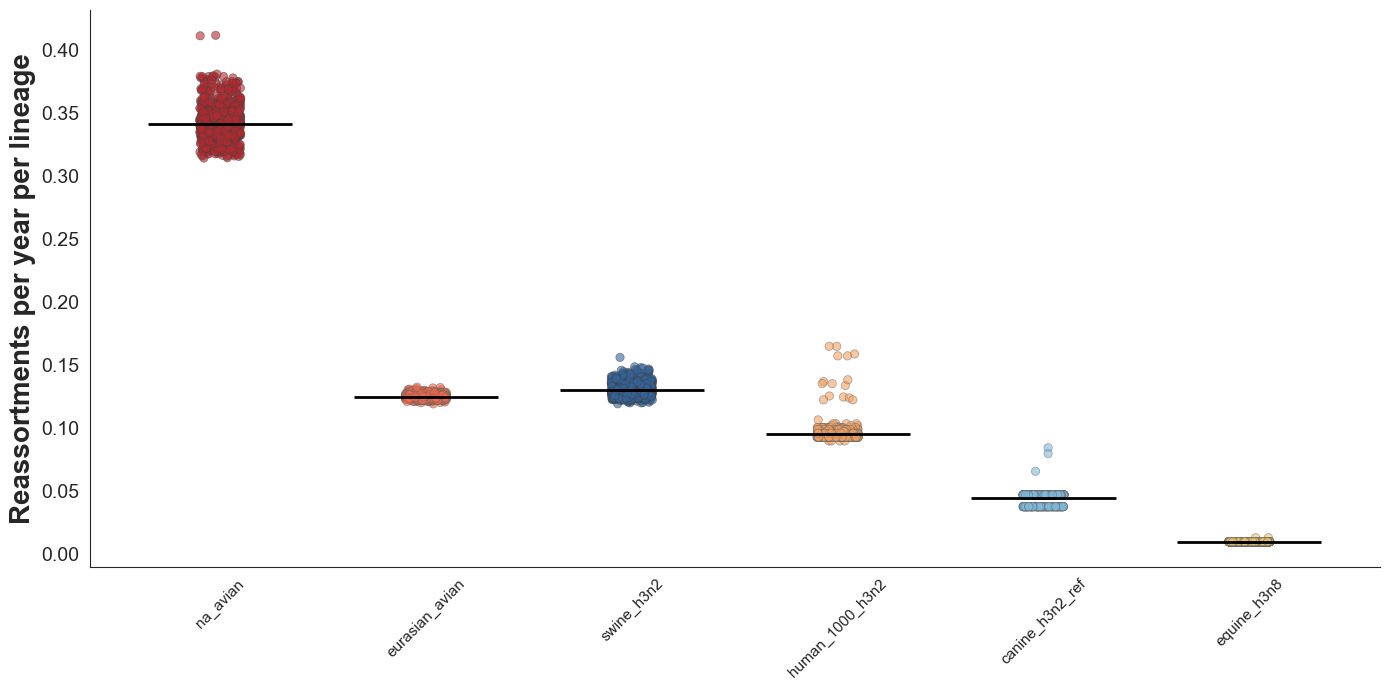

In [2]:
hosts = ["na_avian", "eurasian_avian", "swine_h3n2", "human_1000_h3n2", "canine_h3n2_ref", "equine_h3n8"]

host_colors = {
    "na_avian": "#b6282e",
    "eurasian_avian": "#fb6a4a", 
    "swine_h3n2": "#33659e",
    "human_1000_h3n2": "#f4a261",
    "canine_h3n2_ref": "#7fbadc",
    "equine_h3n8": "#e9c46a"
}

files = glob.glob("logs-95/*.csv")
dfs = []
for f in files:
    df = pd.read_csv(f)
    host_name = os.path.basename(f).replace(".csv", "")
    df["source"] = host_name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data["source"] = pd.Categorical(data["source"], categories=hosts, ordered=True)

summary = (
    data.groupby("source")["simple_rate"]
    .agg(mean="mean", sd="std", median="median", n="count")
    .reindex(hosts)
)

# Pretty print
for host, row in summary.iterrows():
    print(
        f"{host:15s}  mean ± sd = {row['mean']:.4f} ± {row['sd']:.4f}   "
        f"median = {row['median']:.4f}   (n={int(row['n'])})"
    )
    
plt.figure(figsize=(14, 7))
sns.set_style("white")

plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

sns.stripplot(
    x="source", y="simple_rate",
    data=data, size=6, jitter=True, alpha=0.6, order=hosts,
    palette=host_colors, linewidth=0.5
)

for i, host in enumerate(hosts):
    mean_val = data[data["source"] == host]["simple_rate"].mean()
    plt.hlines(mean_val, i - 0.35, i + 0.35, colors="black", linewidth=2, zorder=3)
    plt.scatter(i, mean_val, color="black", s=300, marker="_", zorder=4, linewidths=2)

sns.despine()
plt.xticks(rotation=45, fontsize=11, fontname='Arial')
plt.yticks(fontsize=14, fontname='Arial')
plt.ylabel("Reassortments per year per lineage", fontsize=20, fontweight="bold", fontname='Arial')
plt.xlabel("", fontsize=20, fontweight="bold", fontname='Arial')
plt.tight_layout()
plt.savefig("plots/rea_rates.pdf", dpi=300, bbox_inches="tight")
plt.show()